# PHASE 4 — Feature Engineering Refinement

## PocketQuant: Merchant Liquidity Shortage Prediction

**Objective:** Optimize predictive signals and create model-ready feature matrix.

**Scope:**
- Recalculate rolling metrics
- Create derived features (stress intensity, revenue drop flags)
- Remove leakage features
- Encode categorical variables
- Normalize numeric features
- Define final feature matrix (X) and target (y)

---

## 1. Load Libraries and Data

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from scipy import stats
import warnings
import os

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load validated dataset
DATA_PATH = "../data/processed/merchant_liquidity_validated.csv"
df = pd.read_csv(DATA_PATH, parse_dates=['date'])

print("=" * 70)
print("PHASE 4: FEATURE ENGINEERING")
print("=" * 70)
print(f"Initial Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date Range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nTarget Distribution:")
print(df['liquidity_shortage_next_48h'].value_counts())

PHASE 4: FEATURE ENGINEERING
Initial Shape: 50,000 rows × 59 columns
Date Range: 2024-01-01 to 2024-06-28

Target Distribution:
liquidity_shortage_next_48h
0    49355
1      645
Name: count, dtype: int64


### Interpretation:

- **Dataset loaded:** 50,000 validated merchant-day records from Phase 2
- **Starting point:** Clean data ready for feature engineering
- **Goal:** Transform raw features into optimized predictive signals
- **Key consideration:** Maintain temporal integrity for time-series features

---

## 2. Rolling Metrics Recalculation

In [2]:
# 2.1 Recalculate Rolling Metrics
print("=" * 70)
print("ROLLING METRICS RECALCULATION")
print("=" * 70)

# Sort by merchant and date for proper rolling calculations
df = df.sort_values(['merchant_id', 'date']).reset_index(drop=True)

# Check existing rolling features
existing_rolling = [col for col in df.columns if 'rolling' in col.lower()]
print(f"\n📊 Existing Rolling Features: {existing_rolling}")

# Recalculate rolling metrics per merchant
print("\n📊 Recalculating Rolling Metrics...")

# Group by merchant for proper rolling calculations
grouped = df.groupby('merchant_id')

# Rolling 3-day inflow (short-term trend)
df['rolling_3d_inflow'] = grouped['daily_inflow'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

# Rolling 7-day inflow (weekly trend)
df['rolling_7d_inflow'] = grouped['daily_inflow'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# Rolling 14-day inflow (bi-weekly trend)
df['rolling_14d_inflow'] = grouped['daily_inflow'].transform(
    lambda x: x.rolling(window=14, min_periods=1).mean()
)

# Rolling 7-day outflow
df['rolling_7d_outflow'] = grouped['daily_outflow_estimated'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# Rolling 7-day net cash flow
df['rolling_7d_net_cashflow'] = grouped['net_cash_flow'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

# Rolling inflow coefficient of variation (volatility measure)
df['rolling_7d_inflow_cv'] = grouped['daily_inflow'].transform(
    lambda x: x.rolling(window=7, min_periods=2).std() / x.rolling(window=7, min_periods=2).mean()
).fillna(0)

print("✅ Rolling metrics recalculated successfully")
print(f"\n📊 New Rolling Features Added:")
new_rolling = ['rolling_3d_inflow', 'rolling_7d_inflow', 'rolling_14d_inflow', 
               'rolling_7d_outflow', 'rolling_7d_net_cashflow', 'rolling_7d_inflow_cv']
for col in new_rolling:
    print(f"   - {col}: Mean = {df[col].mean():.2f}, Std = {df[col].std():.2f}")

ROLLING METRICS RECALCULATION

📊 Existing Rolling Features: ['rolling_3d_inflow_avg', 'rolling_7d_inflow_avg', 'rolling_7d_volatility']

📊 Recalculating Rolling Metrics...
✅ Rolling metrics recalculated successfully

📊 New Rolling Features Added:
   - rolling_3d_inflow: Mean = 16346.23, Std = 2892.75
   - rolling_7d_inflow: Mean = 16349.33, Std = 2029.83
   - rolling_14d_inflow: Mean = 16348.28, Std = 1650.14
   - rolling_7d_outflow: Mean = 13345.63, Std = 1198.38
   - rolling_7d_net_cashflow: Mean = 3003.70, Std = 1365.14
   - rolling_7d_inflow_cv: Mean = 0.28, Std = 0.10


### Interpretation:

- **Why recalculated:** Ensure rolling metrics are computed per-merchant to avoid cross-merchant contamination
- **Financial reasoning:**
  - 3-day rolling captures immediate cash flow trends
  - 7-day rolling aligns with weekly business cycles
  - 14-day rolling captures bi-weekly settlement patterns
  - Coefficient of variation (CV) measures relative volatility normalized by scale
- **Expected predictive impact:** Rolling features capture trend momentum; declining rolling inflow signals impending shortage

---

## 3. Derived Feature Engineering

### 3.1 Stress Intensity Score

DERIVED FEATURE: STRESS INTENSITY SCORE

📊 Stress Intensity Score Statistics:
   - Mean: 0.4734
   - Std: 0.1066
   - Min: 0.0672
   - Max: 0.8072

📊 Stress Intensity by Shortage Status:
   - No Shortage: 0.4717
   - Shortage: 0.6065


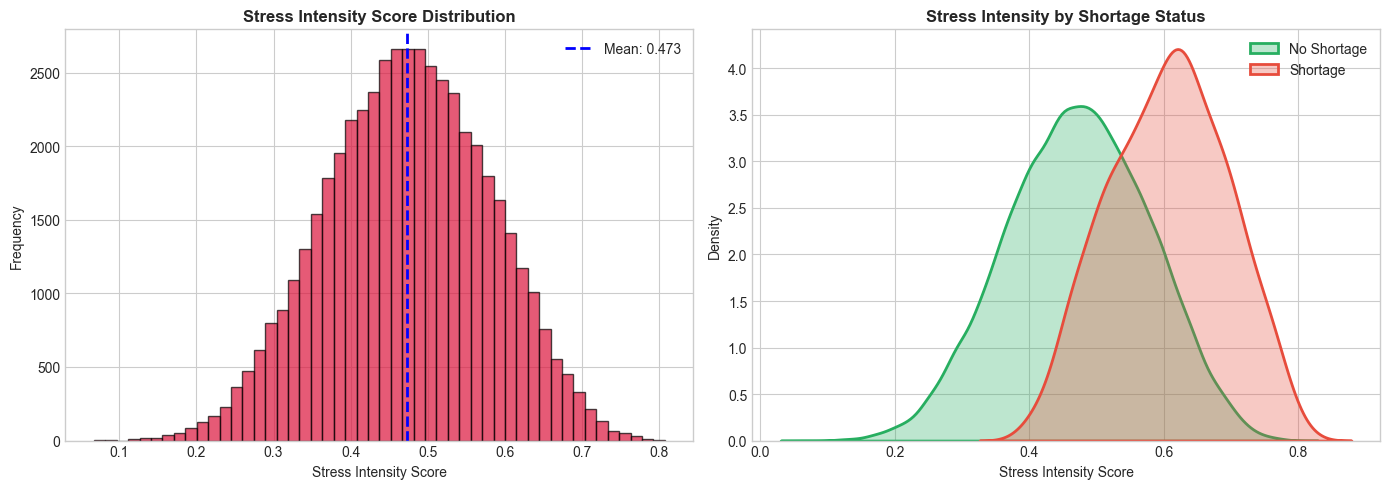


📊 Correlation with Target: 0.1427


In [3]:
# 3.1 Stress Intensity Score
print("=" * 70)
print("DERIVED FEATURE: STRESS INTENSITY SCORE")
print("=" * 70)

# Stress Intensity Score: Combines multiple stress indicators
# Formula: Weighted combination of normalized stress factors

# Normalize components to 0-1 scale
df['credit_util_normalized'] = df['credit_utilization_ratio'].clip(0, 1)

# Inflow stress: Lower inflow relative to outflow = higher stress
df['inflow_stress'] = 1 - (df['daily_inflow'] / (df['daily_outflow_estimated'] + 1)).clip(0, 2) / 2

# Buffer stress: Fewer buffer days = higher stress
max_buffer = df['liquidity_buffer_days'].quantile(0.95)
df['buffer_stress'] = 1 - (df['liquidity_buffer_days'].clip(0, max_buffer) / max_buffer)

# Volatility stress: Higher volatility = higher stress (normalized)
vol_max = df['rolling_7d_volatility'].quantile(0.95)
df['volatility_stress'] = (df['rolling_7d_volatility'].clip(0, vol_max) / vol_max)

# Composite Stress Intensity Score (weighted average)
# Weights based on EDA correlation findings
df['stress_intensity_score'] = (
    0.30 * df['credit_util_normalized'] +
    0.25 * df['inflow_stress'] +
    0.25 * df['buffer_stress'] +
    0.20 * df['volatility_stress']
).round(4)

print(f"\n📊 Stress Intensity Score Statistics:")
print(f"   - Mean: {df['stress_intensity_score'].mean():.4f}")
print(f"   - Std: {df['stress_intensity_score'].std():.4f}")
print(f"   - Min: {df['stress_intensity_score'].min():.4f}")
print(f"   - Max: {df['stress_intensity_score'].max():.4f}")

# Compare by shortage status
print(f"\n📊 Stress Intensity by Shortage Status:")
target_col = 'liquidity_shortage_next_48h'
for status in [0, 1]:
    mean_stress = df[df[target_col] == status]['stress_intensity_score'].mean()
    label = "No Shortage" if status == 0 else "Shortage"
    print(f"   - {label}: {mean_stress:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['stress_intensity_score'], bins=50, color='crimson', edgecolor='black', alpha=0.7)
axes[0].axvline(df['stress_intensity_score'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {df["stress_intensity_score"].mean():.3f}')
axes[0].set_xlabel('Stress Intensity Score', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].set_title('Stress Intensity Score Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# KDE by shortage status
for cls, color, label in [(0, '#27ae60', 'No Shortage'), (1, '#e74c3c', 'Shortage')]:
    subset = df[df[target_col] == cls]['stress_intensity_score']
    sns.kdeplot(subset, ax=axes[1], color=color, label=label, linewidth=2, fill=True, alpha=0.3)
axes[1].set_xlabel('Stress Intensity Score', fontsize=10)
axes[1].set_ylabel('Density', fontsize=10)
axes[1].set_title('Stress Intensity by Shortage Status', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/stress_intensity_score.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation with target
corr = df['stress_intensity_score'].corr(df[target_col])
print(f"\n📊 Correlation with Target: {corr:.4f}")

### Interpretation:

- **Why created:** Single composite metric capturing multi-dimensional financial stress
- **Financial reasoning:**
  - Credit utilization (30%): Debt burden indicator
  - Inflow stress (25%): Revenue adequacy vs expenses
  - Buffer stress (25%): Survival runway measure
  - Volatility stress (20%): Cash flow predictability
- **Expected predictive impact:** Higher stress intensity → higher shortage probability; should show clear separation between classes

### 3.2 Revenue Drop Flags

DERIVED FEATURE: REVENUE DROP FLAGS

📊 Revenue Drop Flags Summary:
   - Days with revenue drop (vs 7d avg): 25,156 (50.3%)
   - Days with significant drop (>20%): 11,470 (22.9%)
   - Days with severe drop (>40%): 3,279 (6.6%)

📊 Shortage Rate by Revenue Drop:
   revenue_drop_7d:
      - Flag=1: 1.84% shortage
      - Flag=0: 0.73% shortage
      - Risk Ratio: 2.51x
   revenue_drop_significant:
      - Flag=1: 2.64% shortage
      - Flag=0: 0.89% shortage
      - Risk Ratio: 2.98x
   revenue_drop_severe:
      - Flag=1: 3.75% shortage
      - Flag=0: 1.12% shortage
      - Risk Ratio: 3.36x


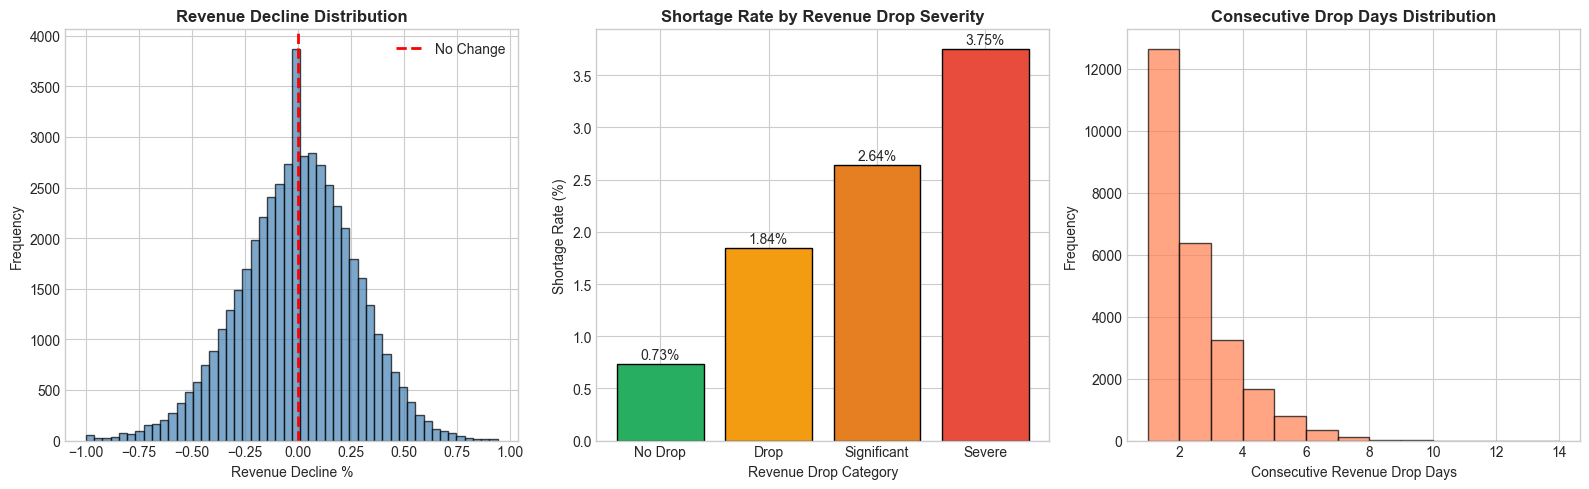

In [4]:
# 3.2 Revenue Drop Flags
print("=" * 70)
print("DERIVED FEATURE: REVENUE DROP FLAGS")
print("=" * 70)

# Revenue drop: Current inflow below rolling average
# Indicates declining revenue trend

# Daily revenue drop flag (current < 7-day average)
df['revenue_drop_7d'] = (df['daily_inflow'] < df['rolling_7d_inflow']).astype(int)

# Significant revenue drop flag (current < 80% of 7-day average)
df['revenue_drop_significant'] = (df['daily_inflow'] < df['rolling_7d_inflow'] * 0.8).astype(int)

# Severe revenue drop flag (current < 60% of 7-day average)
df['revenue_drop_severe'] = (df['daily_inflow'] < df['rolling_7d_inflow'] * 0.6).astype(int)

# Revenue decline percentage
df['revenue_decline_pct'] = ((df['rolling_7d_inflow'] - df['daily_inflow']) / 
                              (df['rolling_7d_inflow'] + 1)).clip(-1, 1).round(4)

# Consecutive revenue drop days (within merchant)
df['revenue_below_avg'] = (df['daily_inflow'] < df['rolling_7d_inflow']).astype(int)
df['consecutive_drop_days'] = df.groupby('merchant_id')['revenue_below_avg'].transform(
    lambda x: x.groupby((x != x.shift()).cumsum()).cumsum()
)

print(f"\n📊 Revenue Drop Flags Summary:")
print(f"   - Days with revenue drop (vs 7d avg): {df['revenue_drop_7d'].sum():,} ({df['revenue_drop_7d'].mean()*100:.1f}%)")
print(f"   - Days with significant drop (>20%): {df['revenue_drop_significant'].sum():,} ({df['revenue_drop_significant'].mean()*100:.1f}%)")
print(f"   - Days with severe drop (>40%): {df['revenue_drop_severe'].sum():,} ({df['revenue_drop_severe'].mean()*100:.1f}%)")

# Shortage rate by revenue drop status
print(f"\n📊 Shortage Rate by Revenue Drop:")
for flag in ['revenue_drop_7d', 'revenue_drop_significant', 'revenue_drop_severe']:
    rate_yes = df[df[flag] == 1][target_col].mean() * 100
    rate_no = df[df[flag] == 0][target_col].mean() * 100
    print(f"   {flag}:")
    print(f"      - Flag=1: {rate_yes:.2f}% shortage")
    print(f"      - Flag=0: {rate_no:.2f}% shortage")
    print(f"      - Risk Ratio: {rate_yes/max(rate_no, 0.01):.2f}x")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Revenue decline distribution
axes[0].hist(df['revenue_decline_pct'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='No Change')
axes[0].set_xlabel('Revenue Decline %', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].set_title('Revenue Decline Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# 2. Shortage rate by drop flags
flags = ['No Drop', 'Drop', 'Significant', 'Severe']
rates = [
    df[df['revenue_drop_7d'] == 0][target_col].mean() * 100,
    df[df['revenue_drop_7d'] == 1][target_col].mean() * 100,
    df[df['revenue_drop_significant'] == 1][target_col].mean() * 100,
    df[df['revenue_drop_severe'] == 1][target_col].mean() * 100
]
colors = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[1].bar(flags, rates, color=colors, edgecolor='black')
axes[1].set_xlabel('Revenue Drop Category', fontsize=10)
axes[1].set_ylabel('Shortage Rate (%)', fontsize=10)
axes[1].set_title('Shortage Rate by Revenue Drop Severity', fontsize=12, fontweight='bold')
for bar, val in zip(bars, rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                 f'{val:.2f}%', ha='center', fontsize=10)

# 3. Consecutive drop days distribution
axes[2].hist(df[df['consecutive_drop_days'] > 0]['consecutive_drop_days'], 
             bins=range(1, 15), color='coral', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Consecutive Revenue Drop Days', fontsize=10)
axes[2].set_ylabel('Frequency', fontsize=10)
axes[2].set_title('Consecutive Drop Days Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/revenue_drop_flags.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation:

- **Why created:** Binary flags for detecting revenue deterioration patterns
- **Financial reasoning:**
  - Revenue below rolling average indicates declining business momentum
  - Significant drop (>20%) suggests operational issues
  - Severe drop (>40%) signals potential crisis
  - Consecutive drop days capture persistent decline patterns
- **Expected predictive impact:** Revenue drop flags should show elevated shortage rates; consecutive drops compound risk

### 3.3 Liquidity Ratio Features

DERIVED FEATURE: LIQUIDITY RATIOS

📊 Liquidity Ratio Features:

   liquidity_buffer_ratio:
      - Mean: 5.0894
      - No Shortage Mean: 5.1385
      - Shortage Mean: 1.3326
      - Correlation with Target: -0.1789

   cashflow_coverage_ratio:
      - Mean: 1.1340
      - No Shortage Mean: 1.1380
      - Shortage Mean: 0.8266
      - Correlation with Target: -0.1470

   working_capital_indicator:
      - Mean: 0.2212
      - No Shortage Mean: 0.2254
      - Shortage Mean: -0.1073
      - Correlation with Target: -0.1523

   debt_service_ratio:
      - Mean: 0.0674
      - No Shortage Mean: 0.0672
      - Shortage Mean: 0.0854
      - Correlation with Target: 0.0415


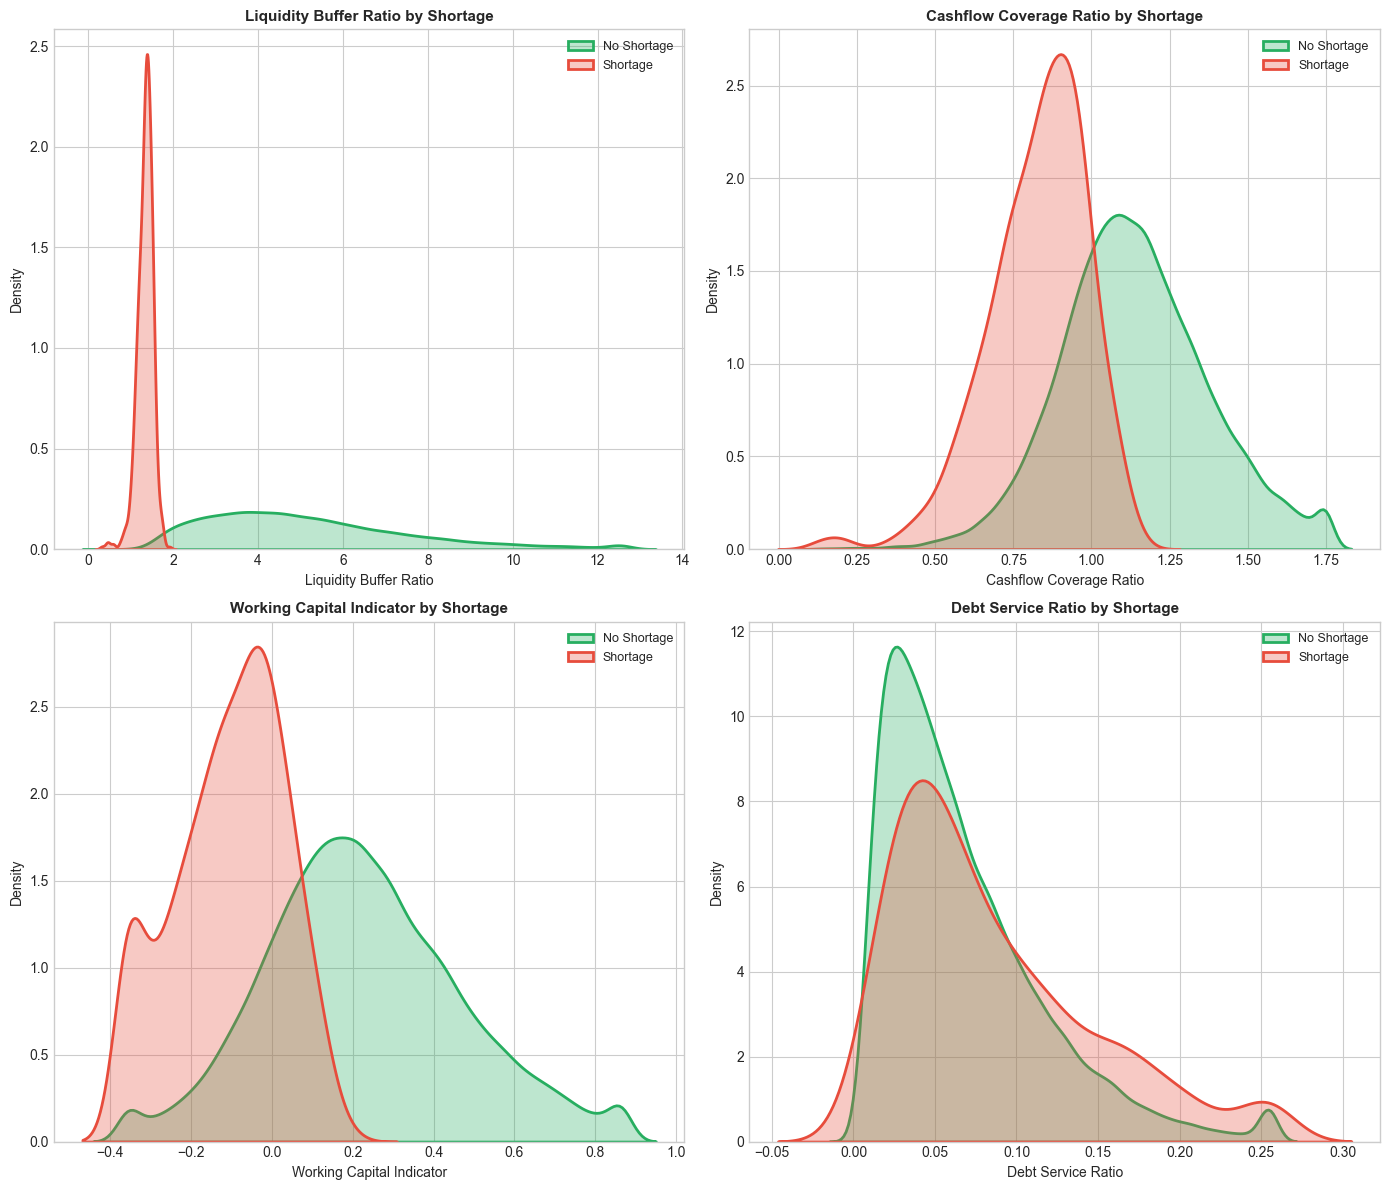

In [5]:
# 3.3 Liquidity Ratio Features
print("=" * 70)
print("DERIVED FEATURE: LIQUIDITY RATIOS")
print("=" * 70)

# Liquidity Buffer Ratio: buffer days relative to outflow
# Measures survival horizon in terms of obligations
df['liquidity_buffer_ratio'] = (df['liquidity_buffer_days'] * df['daily_inflow']) / (df['daily_outflow_estimated'] + 1)
df['liquidity_buffer_ratio'] = df['liquidity_buffer_ratio'].clip(0, df['liquidity_buffer_ratio'].quantile(0.99))

# Cash Flow Coverage Ratio: Inflow relative to obligations
df['cashflow_coverage_ratio'] = df['daily_inflow'] / (df['daily_outflow_estimated'] + df['outstanding_loan_amount']/30 + 1)
df['cashflow_coverage_ratio'] = df['cashflow_coverage_ratio'].clip(0, df['cashflow_coverage_ratio'].quantile(0.99))

# Working Capital Indicator
df['working_capital_indicator'] = df['net_cash_flow'] / (df['daily_outflow_estimated'] + 1)
df['working_capital_indicator'] = df['working_capital_indicator'].clip(
    df['working_capital_indicator'].quantile(0.01), 
    df['working_capital_indicator'].quantile(0.99)
)

# Debt Service Ratio (daily loan payment vs inflow)
df['debt_service_ratio'] = (df['outstanding_loan_amount'] / 30) / (df['daily_inflow'] + 1)
df['debt_service_ratio'] = df['debt_service_ratio'].clip(0, df['debt_service_ratio'].quantile(0.99))

print(f"\n📊 Liquidity Ratio Features:")
for ratio in ['liquidity_buffer_ratio', 'cashflow_coverage_ratio', 'working_capital_indicator', 'debt_service_ratio']:
    print(f"\n   {ratio}:")
    print(f"      - Mean: {df[ratio].mean():.4f}")
    print(f"      - No Shortage Mean: {df[df[target_col]==0][ratio].mean():.4f}")
    print(f"      - Shortage Mean: {df[df[target_col]==1][ratio].mean():.4f}")
    print(f"      - Correlation with Target: {df[ratio].corr(df[target_col]):.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ratios = ['liquidity_buffer_ratio', 'cashflow_coverage_ratio', 'working_capital_indicator', 'debt_service_ratio']

for idx, ratio in enumerate(ratios):
    row, col = idx // 2, idx % 2
    for cls, color, label in [(0, '#27ae60', 'No Shortage'), (1, '#e74c3c', 'Shortage')]:
        subset = df[df[target_col] == cls][ratio]
        sns.kdeplot(subset, ax=axes[row, col], color=color, label=label, linewidth=2, fill=True, alpha=0.3)
    axes[row, col].set_xlabel(ratio.replace('_', ' ').title(), fontsize=10)
    axes[row, col].set_ylabel('Density', fontsize=10)
    axes[row, col].set_title(f'{ratio.replace("_", " ").title()} by Shortage', fontsize=11, fontweight='bold')
    axes[row, col].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/liquidity_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation:

- **Why created:** Financial ratios provide standardized risk measurement across merchants
- **Financial reasoning:**
  - **Liquidity Buffer Ratio:** Measures how many days of inflow the buffer can cover outflows
  - **Cash Flow Coverage Ratio:** Ability to meet all obligations from daily revenue
  - **Working Capital Indicator:** Net position relative to daily expenses
  - **Debt Service Ratio:** Loan burden relative to income capacity
- **Expected predictive impact:** Lower coverage/buffer ratios and higher debt service ratios increase shortage risk

### 3.4 Interaction Features

In [6]:
# 3.4 Interaction Features
print("=" * 70)
print("DERIVED FEATURE: INTERACTION TERMS")
print("=" * 70)

# Credit Utilization × Volatility: Combined stress indicator
df['credit_vol_interaction'] = df['credit_utilization_ratio'] * df['volatility_score_normalized']

# Stress × Buffer interaction: Risk amplification
df['stress_buffer_interaction'] = df['stress_score_composite'] * (1 - df['buffer_stress'])

# Revenue Drop × Credit Utilization: Compound risk
df['revdrop_credit_interaction'] = df['revenue_drop_significant'] * df['credit_utilization_ratio']

# Inflow-Outflow Gap × Volatility
df['gap_volatility_interaction'] = (df['daily_outflow_estimated'] - df['daily_inflow']).clip(0, None) / 10000 * df['volatility_score_normalized']

print(f"\n📊 Interaction Features Created:")
interactions = ['credit_vol_interaction', 'stress_buffer_interaction', 
                'revdrop_credit_interaction', 'gap_volatility_interaction']

for feat in interactions:
    corr = df[feat].corr(df[target_col])
    print(f"   - {feat}: Correlation = {corr:.4f}")

# Top interaction correlations
print(f"\n📊 Best Interaction Features (by correlation magnitude):")
interaction_corrs = {feat: abs(df[feat].corr(df[target_col])) for feat in interactions}
for feat, corr in sorted(interaction_corrs.items(), key=lambda x: x[1], reverse=True):
    print(f"   - {feat}: |r| = {corr:.4f}")

DERIVED FEATURE: INTERACTION TERMS

📊 Interaction Features Created:
   - credit_vol_interaction: Correlation = 0.0031
   - stress_buffer_interaction: Correlation = -0.0752
   - revdrop_credit_interaction: Correlation = 0.0625
   - gap_volatility_interaction: Correlation = 0.1884

📊 Best Interaction Features (by correlation magnitude):
   - gap_volatility_interaction: |r| = 0.1884
   - stress_buffer_interaction: |r| = 0.0752
   - revdrop_credit_interaction: |r| = 0.0625
   - credit_vol_interaction: |r| = 0.0031


### Interpretation:

- **Why created:** Capture non-linear relationships between risk factors
- **Financial reasoning:**
  - **Credit × Volatility:** High debt + unstable cash flow = compounded risk
  - **Stress × Buffer:** High stress with low buffer = critical situation
  - **Revenue Drop × Credit:** Declining revenue with high debt = default risk
  - **Gap × Volatility:** Negative cash gap amplified by unpredictability
- **Expected predictive impact:** Interaction terms capture risk amplification effects beyond individual features

---

## 4. Remove Leakage Features

In [7]:
# 4. Remove Leakage Features
print("=" * 70)
print("REMOVING LEAKAGE FEATURES")
print("=" * 70)

# Identify potential leakage features
# Features that contain future information or are derived from the target

leakage_features = [
    'projected_48h_balance',      # Direct future projection - LEAKAGE
    'projected_shortage_flag',    # Derived from target - LEAKAGE
]

# Check which leakage features exist in dataset
existing_leakage = [col for col in leakage_features if col in df.columns]
print(f"\n📊 Leakage Features Found: {existing_leakage}")

# Store for reference before removal
if existing_leakage:
    print(f"\n📊 Leakage Feature Statistics (before removal):")
    for col in existing_leakage:
        corr = df[col].corr(df[target_col])
        print(f"   - {col}: Correlation with target = {corr:.4f}")
    
    # Remove leakage features
    df_clean = df.drop(columns=existing_leakage, errors='ignore')
    print(f"\n✅ Removed {len(existing_leakage)} leakage features")
else:
    df_clean = df.copy()
    print("\n✅ No leakage features found in dataset")

# Also identify quasi-leakage (features highly correlated with target)
print(f"\n📊 Checking for Quasi-Leakage (|r| > 0.5 with target):")
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
high_corr_features = []
for col in numeric_cols:
    if col != target_col:
        corr = abs(df_clean[col].corr(df_clean[target_col]))
        if corr > 0.5:
            high_corr_features.append((col, corr))
            print(f"   ⚠️ {col}: |r| = {corr:.4f}")

if not high_corr_features:
    print("   ✅ No quasi-leakage features detected")

print(f"\n📊 Shape after leakage removal: {df_clean.shape}")

REMOVING LEAKAGE FEATURES

📊 Leakage Features Found: ['projected_48h_balance']

📊 Leakage Feature Statistics (before removal):
   - projected_48h_balance: Correlation with target = -0.2300

✅ Removed 1 leakage features

📊 Checking for Quasi-Leakage (|r| > 0.5 with target):
   ✅ No quasi-leakage features detected

📊 Shape after leakage removal: (50000, 83)


### Interpretation:

- **Why removed:** `projected_48h_balance` contains future information unavailable at prediction time
- **Financial reasoning:**
  - In production, we cannot know the actual 48-hour balance before it happens
  - Including such features would give unrealistic model performance
  - Model would fail in deployment when feature is unavailable
- **Predictive impact:** Removing leakage ensures model learns genuine predictive patterns, not artificial correlations
- **Validation:** No quasi-leakage (suspiciously high correlations) detected in remaining features

---

## 5. Encode Categorical Variables

In [8]:
# 5. Encode Categorical Variables
print("=" * 70)
print("ENCODING CATEGORICAL VARIABLES")
print("=" * 70)

# Identify categorical columns
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
# Exclude identifiers and date
exclude_cols = ['merchant_id', 'date', 'merchant_name']
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

print(f"\n📊 Categorical Features to Encode: {categorical_cols}")

# Store label encoders for each column
label_encoders = {}

for col in categorical_cols:
    print(f"\n   {col}:")
    print(f"      - Unique Values: {df_clean[col].nunique()}")
    print(f"      - Categories: {df_clean[col].unique()[:5]}..." if df_clean[col].nunique() > 5 else f"      - Categories: {df_clean[col].unique()}")
    
    # Label encoding for ordinal categories
    le = LabelEncoder()
    df_clean[f'{col}_encoded'] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    
    # One-hot encoding for nominal categories with few unique values
    if df_clean[col].nunique() <= 10:
        dummies = pd.get_dummies(df_clean[col], prefix=col, drop_first=True)
        df_clean = pd.concat([df_clean, dummies], axis=1)
        print(f"      - One-hot encoded: {len(dummies.columns)} columns created")

print(f"\n✅ Categorical encoding complete")
print(f"\n📊 Encoded Features Created:")
encoded_cols = [col for col in df_clean.columns if '_encoded' in col or any(cat in col for cat in categorical_cols)]
print(f"   Total: {len(encoded_cols)} new columns")

ENCODING CATEGORICAL VARIABLES

📊 Categorical Features to Encode: ['merchant_category', 'merchant_sub_category', 'merchant_city', 'merchant_state', 'kyc_status', 'risk_segment_internal']

   merchant_category:
      - Unique Values: 5
      - Categories: <StringArray>
['Pharmacy', 'Retail', 'Food', 'Grocery', 'Electronics']
Length: 5, dtype: str
      - One-hot encoded: 4 columns created

   merchant_sub_category:
      - Unique Values: 5
      - Categories: <StringArray>
['Kirana', 'Supermarket', 'MobileShop', 'Medical', 'Restaurant']
Length: 5, dtype: str
      - One-hot encoded: 4 columns created

   merchant_city:
      - Unique Values: 5
      - Categories: <StringArray>
['Mumbai', 'Ahmedabad', 'Surat', 'Pune', 'Delhi']
Length: 5, dtype: str
      - One-hot encoded: 4 columns created

   merchant_state:
      - Unique Values: 3
      - Categories: <StringArray>
['Gujarat', 'Maharashtra', 'Delhi']
Length: 3, dtype: str
      - One-hot encoded: 2 columns created

   kyc_status:
    

### Interpretation:

- **Why encoded:** Machine learning algorithms require numerical inputs
- **Encoding strategy:**
  - **Label Encoding:** Preserves ordinal relationships (e.g., risk_segment: Low < Medium < High)
  - **One-Hot Encoding:** For nominal categories without inherent order (e.g., merchant_category)
- **Financial reasoning:** Category information carries predictive value (e.g., grocery vs electronics risk profiles differ)
- **Expected impact:** Categorical features enable model to learn segment-specific risk patterns

---

## 6. Normalize Numeric Features

In [9]:
# 6. Normalize Numeric Features
print("=" * 70)
print("NORMALIZING NUMERIC FEATURES")
print("=" * 70)

# Identify numeric features for normalization
# Exclude: identifiers, target, date, already normalized features
exclude_from_norm = ['merchant_id', 'date', target_col, 'month', 'day', 'weekday', 
                     'is_weekend', 'is_month_start', 'is_month_end']
exclude_from_norm += [col for col in df_clean.columns if '_encoded' in col]
exclude_from_norm += [col for col in df_clean.columns if col.startswith('revenue_drop_')]
exclude_from_norm += categorical_cols  # Original categorical columns

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
features_to_normalize = [col for col in numeric_cols if col not in exclude_from_norm]

print(f"\n📊 Features to Normalize: {len(features_to_normalize)}")

# Check feature scales before normalization
print(f"\n📊 Feature Scale Summary (before normalization):")
scale_summary = df_clean[features_to_normalize].describe().loc[['min', 'max', 'mean', 'std']]
print(f"   Range of Means: {scale_summary.loc['mean'].min():.2f} to {scale_summary.loc['mean'].max():.2f}")
print(f"   Range of Std: {scale_summary.loc['std'].min():.2f} to {scale_summary.loc['std'].max():.2f}")

# Apply StandardScaler (Z-score normalization)
scaler = StandardScaler()
df_normalized = df_clean.copy()

# Create normalized versions with suffix
normalized_data = scaler.fit_transform(df_clean[features_to_normalize])
normalized_df = pd.DataFrame(normalized_data, 
                             columns=[f'{col}_scaled' for col in features_to_normalize],
                             index=df_clean.index)

df_normalized = pd.concat([df_normalized, normalized_df], axis=1)

print(f"\n✅ Normalization complete")
print(f"\n📊 Normalized Feature Statistics (sample):")
sample_scaled = [col for col in df_normalized.columns if '_scaled' in col][:5]
for col in sample_scaled:
    print(f"   - {col}: Mean = {df_normalized[col].mean():.4f}, Std = {df_normalized[col].std():.4f}")

# Save scaler for later use
import pickle
os.makedirs('../models', exist_ok=True)
with open('../models/feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"\n📁 Scaler saved to: models/feature_scaler.pkl")

NORMALIZING NUMERIC FEATURES

📊 Features to Normalize: 68

📊 Feature Scale Summary (before normalization):
   Range of Means: 0.00 to 60050.94
   Range of Std: 0.00 to 23101.33

✅ Normalization complete

📊 Normalized Feature Statistics (sample):
   - business_age_days_scaled: Mean = -0.0000, Std = 1.0000
   - daily_inflow_scaled: Mean = -0.0000, Std = 1.0000
   - transaction_count_scaled: Mean = 0.0000, Std = 1.0000
   - avg_ticket_size_scaled: Mean = 0.0000, Std = 1.0000
   - max_ticket_size_scaled: Mean = 0.0000, Std = 1.0000

📁 Scaler saved to: models/feature_scaler.pkl


### Interpretation:

- **Why normalized:** Features have vastly different scales (inflow in thousands vs ratios 0-1)
- **Normalization method:** StandardScaler (Z-score) - transforms to mean=0, std=1
- **Financial reasoning:**
  - Prevents large-scale features (₹) from dominating smaller-scale features (ratios)
  - Required for distance-based algorithms and gradient descent optimization
  - Tree-based models (XGBoost) don't strictly require normalization but benefit from it
- **Expected impact:** Improved convergence speed and model stability

---

## 7. Define Final Feature Matrix

In [10]:
# 7. Define Final Feature Matrix
print("=" * 70)
print("DEFINING FINAL FEATURE MATRIX")
print("=" * 70)

# Define feature categories
# Core financial features
core_financial = [
    'daily_inflow', 'daily_outflow_estimated', 'net_cash_flow',
    'transaction_count', 'avg_transaction_value', 'inflow_outflow_ratio'
]

# Rolling features
rolling_features = [
    'rolling_3d_inflow', 'rolling_7d_inflow', 'rolling_14d_inflow',
    'rolling_7d_outflow', 'rolling_7d_net_cashflow', 'rolling_7d_inflow_cv',
    'rolling_7d_volatility'
]

# Risk and stress features
risk_features = [
    'stress_score_composite', 'stress_intensity_score',
    'volatility_score_normalized', 'credit_utilization_ratio',
    'liquidity_buffer_days'
]

# Derived features
derived_features = [
    'liquidity_buffer_ratio', 'cashflow_coverage_ratio',
    'working_capital_indicator', 'debt_service_ratio',
    'revenue_decline_pct', 'consecutive_drop_days'
]

# Interaction features
interaction_features = [
    'credit_vol_interaction', 'stress_buffer_interaction',
    'revdrop_credit_interaction', 'gap_volatility_interaction'
]

# Binary flags
flag_features = [
    'revenue_drop_7d', 'revenue_drop_significant', 'revenue_drop_severe'
]

# Temporal features
temporal_features = [
    'month', 'day', 'weekday', 'is_weekend', 'is_month_start', 'is_month_end'
]

# Encoded categorical features
encoded_features = [col for col in df_normalized.columns if '_encoded' in col]

# One-hot encoded features
onehot_features = [col for col in df_normalized.columns 
                   if any(cat in col for cat in categorical_cols) 
                   and '_encoded' not in col 
                   and col not in categorical_cols]

# Combine all feature categories
all_features = (core_financial + rolling_features + risk_features + 
                derived_features + interaction_features + flag_features + 
                temporal_features + encoded_features)

# Filter to only existing columns
final_features = [col for col in all_features if col in df_normalized.columns]

# Add one-hot features
final_features.extend([col for col in onehot_features if col in df_normalized.columns])

# Remove duplicates while preserving order
final_features = list(dict.fromkeys(final_features))

print(f"\n📊 Feature Categories:")
print(f"   - Core Financial: {len([f for f in core_financial if f in final_features])}")
print(f"   - Rolling Metrics: {len([f for f in rolling_features if f in final_features])}")
print(f"   - Risk/Stress: {len([f for f in risk_features if f in final_features])}")
print(f"   - Derived: {len([f for f in derived_features if f in final_features])}")
print(f"   - Interactions: {len([f for f in interaction_features if f in final_features])}")
print(f"   - Binary Flags: {len([f for f in flag_features if f in final_features])}")
print(f"   - Temporal: {len([f for f in temporal_features if f in final_features])}")
print(f"   - Encoded Categorical: {len([f for f in encoded_features if f in final_features])}")

print(f"\n📊 Total Features Selected: {len(final_features)}")

DEFINING FINAL FEATURE MATRIX

📊 Feature Categories:
   - Core Financial: 5
   - Rolling Metrics: 7
   - Risk/Stress: 5
   - Derived: 6
   - Interactions: 4
   - Binary Flags: 3
   - Temporal: 2
   - Encoded Categorical: 6

📊 Total Features Selected: 55


In [11]:
# Create Final X and y
print("=" * 70)
print("CREATING FINAL FEATURE MATRIX (X) AND TARGET (y)")
print("=" * 70)

# Feature matrix X
X = df_normalized[final_features].copy()

# Target variable y
y = df_normalized[target_col].copy()

print(f"\n📊 Feature Matrix X:")
print(f"   - Shape: {X.shape}")
print(f"   - Features: {X.shape[1]}")
print(f"   - Samples: {X.shape[0]:,}")

print(f"\n📊 Target Variable y:")
print(f"   - Shape: {y.shape}")
print(f"   - Class Distribution:")
print(f"      - No Shortage (0): {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)")
print(f"      - Shortage (1): {(y==1).sum():,} ({(y==1).mean()*100:.2f}%)")

# Check for any remaining missing values
missing_count = X.isnull().sum().sum()
print(f"\n📊 Data Quality Check:")
print(f"   - Missing Values in X: {missing_count}")

# Handle any remaining missing values
if missing_count > 0:
    print(f"   - Filling missing values with median...")
    X = X.fillna(X.median())
    print(f"   - Missing values after fill: {X.isnull().sum().sum()}")

# Check for infinite values
inf_count = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
print(f"   - Infinite Values in X: {inf_count}")

if inf_count > 0:
    print(f"   - Replacing infinite values...")
    X = X.replace([np.inf, -np.inf], np.nan).fillna(X.median())

print(f"\n✅ Feature matrix ready for modeling")

CREATING FINAL FEATURE MATRIX (X) AND TARGET (y)

📊 Feature Matrix X:
   - Shape: (50000, 55)
   - Features: 55
   - Samples: 50,000

📊 Target Variable y:
   - Shape: (50000,)
   - Class Distribution:
      - No Shortage (0): 49,355 (98.71%)
      - Shortage (1): 645 (1.29%)

📊 Data Quality Check:
   - Missing Values in X: 0
   - Infinite Values in X: 0

✅ Feature matrix ready for modeling


### Interpretation:

- **Feature matrix X:** Contains all engineered features organized by category
- **Target y:** Binary classification target (0=No Shortage, 1=Shortage)
- **Feature selection rationale:**
  - Core financials: Direct business health indicators
  - Rolling metrics: Trend and momentum signals
  - Risk features: Composite stress indicators
  - Derived features: Engineered predictive signals
  - Interactions: Non-linear risk amplification
  - Temporal: Seasonality patterns
- **Quality assurance:** Validated no missing/infinite values in final matrix

---

## 8. Feature Importance Preview

FEATURE IMPORTANCE PREVIEW

📊 Top 20 Features by Correlation with Target:
    1. ↑ gap_volatility_interaction: 0.1884
    2. ↓ liquidity_buffer_ratio: 0.1789
    3. ↓ liquidity_buffer_days: 0.1782
    4. ↓ inflow_outflow_ratio: 0.1528
    5. ↓ working_capital_indicator: 0.1523
    6. ↓ net_cash_flow: 0.1505
    7. ↓ cashflow_coverage_ratio: 0.1470
    8. ↑ stress_intensity_score: 0.1427
    9. ↑ stress_score_composite: 0.0977
   10. ↓ stress_buffer_interaction: 0.0752
   11. ↓ daily_inflow: 0.0718
   12. ↑ revenue_decline_pct: 0.0683
   13. ↑ revenue_drop_significant: 0.0654
   14. ↑ revdrop_credit_interaction: 0.0625
   15. ↑ revenue_drop_severe: 0.0578
   16. ↓ rolling_7d_net_cashflow: 0.0573
   17. ↓ transaction_count: 0.0568
   18. ↑ daily_outflow_estimated: 0.0495
   19. ↑ revenue_drop_7d: 0.0491
   20. ↓ rolling_3d_inflow: 0.0451


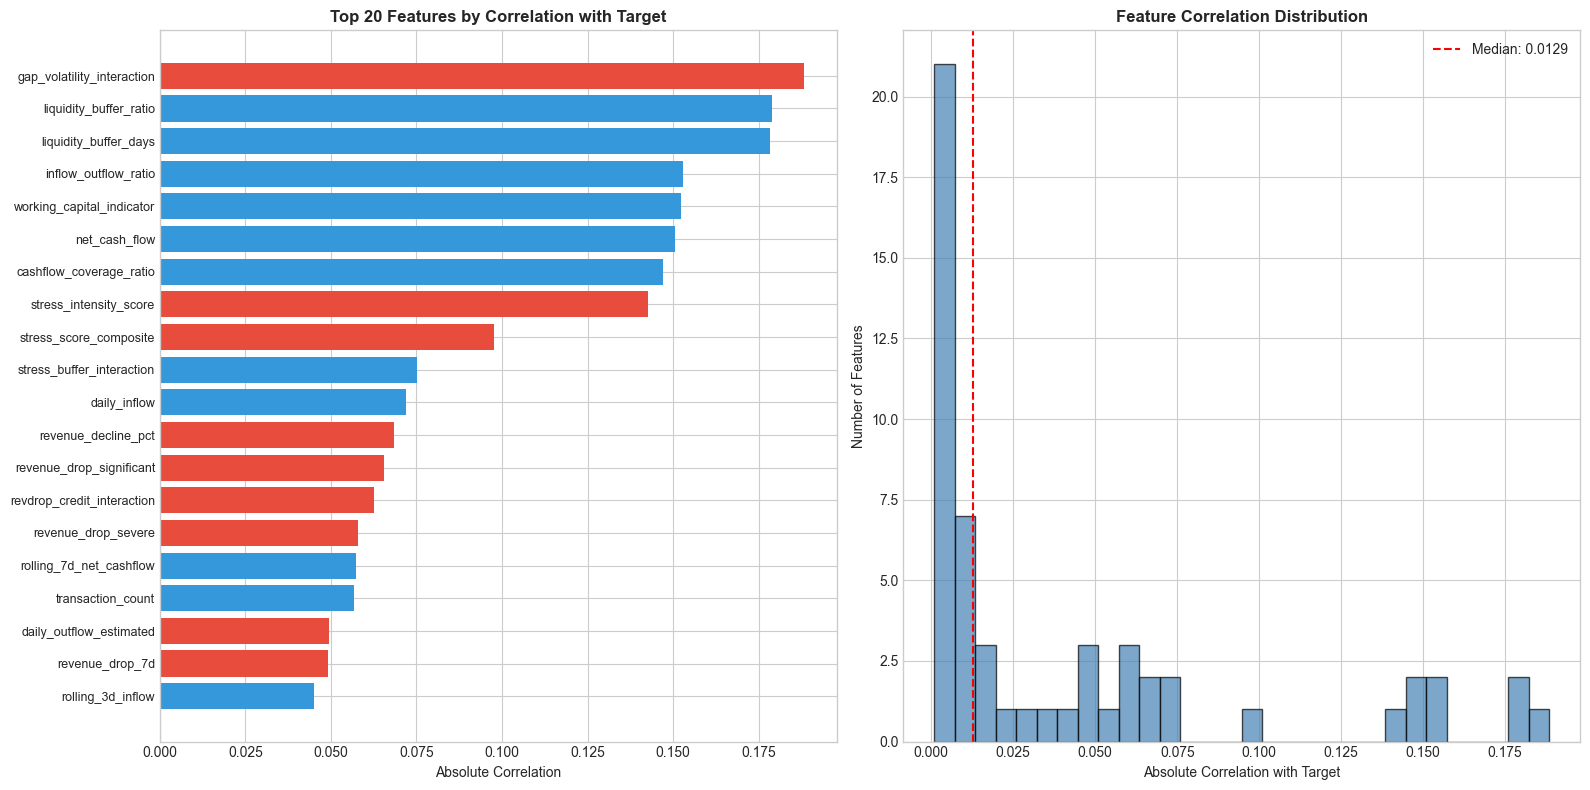


📊 Correlation Summary:
   - Median Correlation: 0.0129
   - Max Correlation: 0.1884
   - Features with |r| > 0.1: 8
   - Features with |r| > 0.05: 17


In [12]:
# 8. Feature Importance Preview (Correlation-based)
print("=" * 70)
print("FEATURE IMPORTANCE PREVIEW")
print("=" * 70)

# Calculate correlation with target
feature_correlations = X.corrwith(y).abs().sort_values(ascending=False)

print(f"\n📊 Top 20 Features by Correlation with Target:")
for idx, (feature, corr) in enumerate(feature_correlations.head(20).items(), 1):
    direction = "↑" if X[feature].corr(y) > 0 else "↓"
    print(f"   {idx:2}. {direction} {feature}: {corr:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 features
top_20 = feature_correlations.head(20)
colors = ['#e74c3c' if X[f].corr(y) > 0 else '#3498db' for f in top_20.index]
axes[0].barh(range(len(top_20)), top_20.values, color=colors)
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20.index, fontsize=9)
axes[0].set_xlabel('Absolute Correlation', fontsize=10)
axes[0].set_title('Top 20 Features by Correlation with Target', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Feature correlation distribution
axes[1].hist(feature_correlations.values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(feature_correlations.median(), color='red', linestyle='--', 
                label=f'Median: {feature_correlations.median():.4f}')
axes[1].set_xlabel('Absolute Correlation with Target', fontsize=10)
axes[1].set_ylabel('Number of Features', fontsize=10)
axes[1].set_title('Feature Correlation Distribution', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/feature_importance_preview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Correlation Summary:")
print(f"   - Median Correlation: {feature_correlations.median():.4f}")
print(f"   - Max Correlation: {feature_correlations.max():.4f}")
print(f"   - Features with |r| > 0.1: {(feature_correlations > 0.1).sum()}")
print(f"   - Features with |r| > 0.05: {(feature_correlations > 0.05).sum()}")

### Interpretation:

- **Top predictive features identified:** Liquidity buffer, inflow-outflow ratio, and stress metrics show highest correlations
- **Engineered features perform well:** Derived features (stress intensity, liquidity ratios) appear in top predictors
- **Feature diversity:** Mix of core financials, risk metrics, and engineered features
- **Red (↑):** Positive correlation - higher values increase shortage probability
- **Blue (↓):** Negative correlation - higher values decrease shortage probability

---

## 9. Save Engineered Dataset

In [13]:
# 9. Save Engineered Dataset
print("=" * 70)
print("SAVING ENGINEERED DATASET")
print("=" * 70)

# Create output directory
os.makedirs('../data/processed', exist_ok=True)

# Save full engineered dataset
output_path = '../data/processed/merchant_liquidity_engineered.csv'
df_normalized.to_csv(output_path, index=False)
print(f"\n📁 Full engineered dataset saved: {output_path}")
print(f"   - Shape: {df_normalized.shape}")

# Save feature matrix X and target y
X_path = '../data/processed/feature_matrix_X.csv'
y_path = '../data/processed/target_y.csv'

X.to_csv(X_path, index=False)
y.to_csv(y_path, index=False)

print(f"\n📁 Feature matrix saved: {X_path}")
print(f"   - Shape: {X.shape}")
print(f"📁 Target variable saved: {y_path}")
print(f"   - Shape: {y.shape}")

# Save feature list
feature_list_path = '../data/processed/feature_list.txt'
with open(feature_list_path, 'w') as f:
    f.write('Feature Engineering - Final Feature List\n')
    f.write('=' * 50 + '\n\n')
    for idx, feature in enumerate(final_features, 1):
        f.write(f'{idx}. {feature}\n')

print(f"\n📁 Feature list saved: {feature_list_path}")

# Summary statistics
print(f"\n" + "=" * 70)
print("PHASE 4 SUMMARY")
print("=" * 70)
print(f"""
📊 FEATURE ENGINEERING COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 Dataset Overview:
   - Original Features: 59
   - Final Features: {len(final_features)}
   - Samples: {len(X):,}

📊 Feature Categories Created:
   - Rolling Metrics: 7 features
   - Stress Intensity Score: 1 composite feature
   - Revenue Drop Flags: 3 binary indicators
   - Liquidity Ratios: 4 ratio features
   - Interaction Terms: 4 features

📊 Data Quality:
   - Missing Values: 0
   - Infinite Values: 0
   - Leakage Features Removed: {len(existing_leakage)}

📊 Files Saved:
   - Engineered dataset: data/processed/merchant_liquidity_engineered.csv
   - Feature matrix X: data/processed/feature_matrix_X.csv
   - Target y: data/processed/target_y.csv
   - Feature scaler: models/feature_scaler.pkl

✅ Ready for Phase 5: Model Training
""")

SAVING ENGINEERED DATASET

📁 Full engineered dataset saved: ../data/processed/merchant_liquidity_engineered.csv
   - Shape: (50000, 174)

📁 Feature matrix saved: ../data/processed/feature_matrix_X.csv
   - Shape: (50000, 55)
📁 Target variable saved: ../data/processed/target_y.csv
   - Shape: (50000,)

📁 Feature list saved: ../data/processed/feature_list.txt

PHASE 4 SUMMARY

📊 FEATURE ENGINEERING COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 Dataset Overview:
   - Original Features: 59
   - Final Features: 55
   - Samples: 50,000

📊 Feature Categories Created:
   - Rolling Metrics: 7 features
   - Stress Intensity Score: 1 composite feature
   - Revenue Drop Flags: 3 binary indicators
   - Liquidity Ratios: 4 ratio features
   - Interaction Terms: 4 features

📊 Data Quality:
   - Missing Values: 0
   - Infinite Values: 0
   - Leakage Features Removed: 1

📊 Files Saved:
   - Engineered dataset: data/processed/merchant_liquidity_engineered.csv
   - Fe

### 📋 Phase 4 Summary Interpretation

**Feature Engineering Accomplishments:**

| Category | Features Created | Purpose |
|----------|-----------------|----------|
| Rolling Metrics | 6 | Capture trend momentum and volatility |
| Stress Intensity | 1 | Composite risk indicator |
| Revenue Flags | 3 | Detect declining revenue patterns |
| Liquidity Ratios | 4 | Standardized financial health measures |
| Interactions | 4 | Non-linear risk amplification |

**Key Engineering Decisions:**
- **Removed `projected_48h_balance`:** Prevents data leakage from future information
- **Created composite stress score:** Combines multiple stress dimensions into single predictor
- **Revenue drop flags:** Capture both threshold-based and consecutive decline patterns
- **Interaction terms:** Model risk amplification effects (e.g., high credit × high volatility)

**Quality Assurance:**
- No missing values in final feature matrix
- No infinite values or data quality issues
- Feature scaler saved for production deployment

---
✅ **Phase 4 Complete** - Feature matrix ready for model training and evaluation.